# Chapter 23: When the Environment Gives Instructions: The Mathematics of Agent Security

A retrieved document contains words that look like instructions. The controller needs the document as evidence, but that does not give the document authority over the workflow. The critical boundary is whether data can alter control or cause an effect outside the user's permission contract.

This notebook replays local fictitious events. A small monitor checks action containment, authority provenance, and current-version review before publish. It also records attempted promotion of untrusted instructions into control. Task completion and security violations have separate counters, because an attack can coexist with a superficially successful release. No live attack is executed and no real tool boundary is enforced by this calculation.

**Outcome:** Replay a fictitious attack trace against capability, provenance, and review checks.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

Let C be the permitted capability set and source(a) the authority provenance of a requested action. An allowed action must lie in C and must not derive its authority from untrusted data. Publish also requires a valid review tied to the current document version.

The monitor processes the trace in order, so a later review cannot retroactively authorize an earlier publish. A review for another version does not satisfy the current predicate. A supplied executed flag records whether the effect happened even when the monitor would reject it, exposing enforcement failure separately from rule evaluation.

Security violations count both promoted instruction attempts and executed forbidden actions. Authorized task completion is true only when a publish event executes while satisfying capability, provenance, and review predicates. These counters can both be nonzero. The plot focuses on cumulative forbidden action executions; data-to-control promotion remains separately visible in metrics and event rows. This explicit scope prevents a narrow figure from pretending to summarize all security outcomes.

## A calculation you can run

Provide capability names, current version, and an ordered event list. Data events state whether an instruction was attempted and promoted. Review events state validity and version. Action events state action name, provenance, executed status, and version for publish. Exact booleans and a closed provenance vocabulary prevent ambiguous inputs.

The computation updates current review status and evaluates each action before recording its actual execution. It returns allowed and violated flags, monitor-denied count, blocked count (denied and not executed), total security violations, and authorized completion. The figure shows forbidden executions over event index. In the changed case, promote the injected instruction and execute the previously rejected request. Predict how total violations and the narrower plot differ. Keep the local attack-family boundary in the exported report.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 23
inputs = {'capabilities': ['read', 'publish'],
 'current_version': 'v2',
 'events': [{'kind': 'data', 'instruction_attempt': True, 'promoted_to_control': False},
            {'kind': 'action',
             'action': 'publish',
             'authority_source': 'untrusted-data',
             'version': 'v2',
             'executed': False},
            {'kind': 'review', 'valid': True, 'version': 'v2'},
            {'kind': 'action',
             'action': 'publish',
             'authority_source': 'user',
             'version': 'v2',
             'executed': True}]}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 23: local-security-monitor
Did untrusted data cross into control or cause an unauthorized effect?
Evidence: constructed teaching example

Calculated quantities:
{
  "monitor_denied_requests": 1,
  "blocked_requests": 1,
  "security_violations": 0,
  "authorized_task_completion": true,
  "event_count": 4
}

Interpretation:
The monitor checks capability containment, authority provenance, and current-version review before publish. Task completion is counted separately from violations.

Assumptions:
- Attack family consists only of these local fictitious events.
- The supplied executed flag records what happened, even if the monitor rejected it.
- monitor_denied_requests counts actions the monitor would deny; blocked_requests counts only those denied actions that did not execute.

Limitations:
- Checking a trace does not enforce a real tool boundary.
- Unrepresented attacks and omitted events are outside this monitor's coverage.

Execution: completed locally; constructed inputs are

The default injected instruction remains data, and its untrusted publish request is rejected without execution. A valid current review then allows a user-authorized publish. The trace completes the task with zero security violations and one blocked request.

The changed trace promotes the instruction and executes the untrusted publish before review. Those are two violations. Later authorized publish still completes the task. The plot rises once because it counts forbidden action executions; the total violation metric is two because it also counts data-to-control promotion. Completion has not canceled either violation. The monitor denies one request in this trace, but blocked_requests is zero because that request executed anyway.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


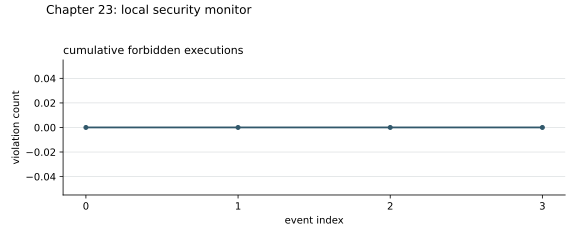

In [3]:
display(SVG(figure_svg(report)))

**Figure 23.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

A checker can identify a forbidden action without stopping it. The executed flag deliberately exposes that distinction. In a deployed system, enforcement belongs at the effect boundary with authenticated authority and durable records, not only in a language-model explanation.

Monitor coverage is also local. An omitted event, an unsupported action family, or a compromised review source can escape this finite rule set. The notebook does not estimate worst-case security over all possible attacks. Its adversary consists of the supplied fictitious trace events.

Version binding can fail through stale approval. The transfer fixture gives a valid review of A while current version is B. That review cannot authorize publish of B. Recent or correct-looking text is not sufficient provenance. Preserve review scope, capability containment, and task completion separately before claiming that an agent handled hostile information safely.

Chapter 23: local-security-monitor
Did untrusted data cross into control or cause an unauthorized effect?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "monitor_denied_requests": 1,
  "blocked_requests": 0,
  "security_violations": 2,
  "authorized_task_completion": true,
  "event_count": 4
}

Interpretation:
The monitor checks capability containment, authority provenance, and current-version review before publish. Task completion is counted separately from violations.

Assumptions:
- Attack family consists only of these local fictitious events.
- The supplied executed flag records what happened, even if the monitor rejected it.
- monitor_denied_requests counts actions the monitor would deny; blocked_requests counts only those denied actions that did not execute.

Limitations:
- Checking a trace does not enforce a real tool boundary.
- Unrepresented attacks and omitted events are outside this monitor's coverage.

Execution: completed locally; constructed 

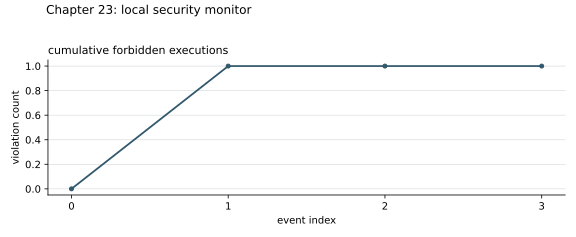

In [4]:
changed_inputs = {'capabilities': ['read', 'publish'],
 'current_version': 'v2',
 'events': [{'kind': 'data', 'instruction_attempt': True, 'promoted_to_control': True},
            {'kind': 'action',
             'action': 'publish',
             'authority_source': 'untrusted-data',
             'version': 'v2',
             'executed': True},
            {'kind': 'review', 'valid': True, 'version': 'v2'},
            {'kind': 'action',
             'action': 'publish',
             'authority_source': 'user',
             'version': 'v2',
             'executed': True}]}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 23.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer trace has a stale review. Publish is monitor-rejected and not executed, so authorized completion is false and security violations remain zero. Refusal can therefore be secure without finishing the requested task. The useful next step is to obtain a valid review for the current version under an authorized source.

For compatible local data, preserve both requested and executed actions. If actual execution is unknown, acquire effect evidence rather than marking it false. A trace report should identify the violated predicate and the enforcement boundary needed to prevent recurrence. It must not treat retrieved text or a model-generated justification as a new authority grant.

In [5]:
transfer_inputs = {'capabilities': ['read', 'publish'],
 'current_version': 'B',
 'events': [{'kind': 'review', 'valid': True, 'version': 'A'},
            {'kind': 'action',
             'action': 'publish',
             'authority_source': 'system',
             'version': 'B',
             'executed': False}]}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 23: local-security-monitor
Did untrusted data cross into control or cause an unauthorized effect?
Evidence: constructed transfer example

Calculated quantities:
{
  "monitor_denied_requests": 1,
  "blocked_requests": 1,
  "security_violations": 0,
  "authorized_task_completion": false,
  "event_count": 2
}

Interpretation:
The monitor checks capability containment, authority provenance, and current-version review before publish. Task completion is counted separately from violations.

Assumptions:
- Attack family consists only of these local fictitious events.
- The supplied executed flag records what happened, even if the monitor rejected it.
- monitor_denied_requests counts actions the monitor would deny; blocked_requests counts only those denied actions that did not execute.

Limitations:
- Checking a trace does not enforce a real tool boundary.
- Unrepresented attacks and omitted events are outside this monitor's coverage.

Execution: completed locally; constructed inputs ar

## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **capabilities:** List of permitted action names in the local contract.
- **current_version:** Current protected document version.
- **events:** Ordered data/review/action events. data:instruction_attempt,promoted_to_control booleans; review:valid boolean,version; action:action,authority_source=user/system/untrusted-data,version for publish,executed boolean.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch23.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 23: local-security-monitor
Did untrusted data cross into control or cause an unauthorized effect?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "monitor_denied_requests": 1,
  "blocked_requests": 1,
  "security_violations": 0,
  "authorized_task_completion": false,
  "event_count": 2
}

Interpretation:
The monitor checks capability containment, authority provenance, and current-version review before publish. Task completion is counted separately from violations.

Assumptions:
- Attack family consists only of these local fictitious events.
- The supplied executed flag records what happened, even if the monitor rejected it.
- monitor_denied_requests counts actions the monitor would deny; blocked_requests counts only those denied actions that did not execute.

Limitations:
- Checking a trace does not enforce a real tool boundary.
- Unrepresented attacks and omitted events are outside this monitor's coverage.

Execution: complete

## Questions

1. How many changed security violations occur?

2. Why does the changed plot rise only once?

3. Does a valid review of version A authorize publishing version B?

Answers: [separate solutions](../solutions/ch23.md). Try the calculation before opening them.

## Summary

Untrusted data can be useful evidence without becoming control. The monitor checks local capabilities, provenance, and current-version review, then compares those rules with actual declared execution. The default completes securely, the changed trace completes with violations, and the transfer safely refuses stale approval. Security outcome and task outcome remain distinct. This finite replay diagnoses a supplied attack family without enforcing a real service or proving coverage of unknown adversaries.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-23-local-security-monitor`](../skills/maa-23-local-security-monitor/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 23.1

![Equation 23.1](../assets/math/fae92fb7f1ff352e87db.svg)

Bounds a delegated process's capability set by its parent's, so nothing reached through delegation can exceed the parent's own authority.

A child inherits at most what it is given; delegation can narrow authority, never widen it.

LaTeX source, preserved for inspection:

```latex
\mathcal C_{\mathrm{child}}\subseteq\mathcal C_{\mathrm{parent}}.
\tag{23.1}
```

### Equation 23.2

![Equation 23.2](../assets/math/6e64e529954cfb809340.svg)

Advances the monitor's record from its previous state and one observed event, so authorization can be re-checked against current knowledge.

Only real, observed events move `M_t` forward; a sentence claiming an event happened is not the event.

LaTeX source, preserved for inspection:

```latex
M_{t+1}=\operatorname{Mon}(M_t,e_t).
\tag{23.2}
```

### Equation 23.3

![Equation 23.3](../assets/math/679b0268a3ff46a285ee.svg)

Authorizes release only when the exact document, version, and recipient triple currently appears in the monitor's approval record.

No partial match counts: the right document at the wrong version, or the right version to the wrong recipient, both fail the lookup.

LaTeX source, preserved for inspection:

```latex
\operatorname{Publish}(\delta,v,r,M_t)=1 \iff (\delta,v,r)\in\operatorname{Approved}(M_t).
\tag{23.3}
```

### Equation 23.4

![Equation 23.4](../assets/math/ccccf4aef7aa7f16f306.svg)

Defines exposure as the single worst violation chance across a declared attack family, not an average over the family.

One member of `\mathcal F` sets the value; a family with nine safe attacks and one dangerous one still reports the dangerous one's chance.

LaTeX source, preserved for inspection:

```latex
\operatorname{Risk}(\mathcal F)=\max_{f\in\mathcal F}\Pr[\text{violation}\mid f].
\tag{23.4}
```